<a href="https://colab.research.google.com/github/ws-isss/cs_HW4/blob/main/cs1090b_hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img style="float: left; padding-right: 15px; width: 35px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png"> CS 1090B: Advanced Topics in Data Science

# Homework 4: Sequence Models, Language Modeling, NER, and Transformers

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, Chris Gumb

<hr style="height:2pt">


<div style="background-color:#fff3cd; color:#222222; border:1px solid #ffeeba; padding:12px 14px; border-radius:10px; margin:10px 0;">
<strong>Run environment:</strong> This homework is designed to be run on a <strong>GPU-enabled environment</strong> such as the course cluster.
The Edward Lear text excerpts and abstract CSV files should live in the notebook's local <code>data/</code> directory.
</div>


<div style="background-color:#d1ecf1; color:#222222; border:1px solid #bee5eb; padding:12px 14px; border-radius:10px; margin:10px 0;">
<strong>Reproducibility / efficiency expectation:</strong> You are expected to write code that <strong>saves</strong> trained model weights
(and any other expensive artifacts) to disk and <strong>loads</strong> them on reruns to avoid unnecessary retraining.
Your notebook should run quickly after the first successful training run.
</div>


## Notebook Contents
<a id = "contents"></a>

- [**Part I: Character-Level Language Modeling**](#part1):
  Text generation in the style of Edward Lear with a PyTorch recurrent network

- [**Part II: Named Entity Recognition**](#part2):
  Sequence tagging with a bidirectional GRU in PyTorch

- [**Part III: Transformer-Based Text Classification**](#part3):
  Fine-tuning BERT (and optionally DeBERTa for 209 students) in PyTorch


In [ ]:

# Standard library
import gc
import math
import os
import pickle
import random
import re
import time
import warnings
from pathlib import Path

# Numerical computing and data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Transformers
import transformers
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Suppress warnings
warnings.filterwarnings("ignore")

SEED = 1090
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = Path("./data")
ARTIFACTS_DIR = Path("./artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

print("device:", DEVICE)
print("transformers version:", transformers.__version__)


device: cuda
transformers version: 5.0.0


In [ ]:

# measure notebook runtime
time_start = time.time()


In [ ]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import os, gdown
    from google.colab import drive

    # Pin transformers to match the course cluster environment.
    # NOTE: after this installs, Colab will prompt you to restart the runtime.
    # Do so, then re-run this cell before continuing.
    %pip install -q "transformers==4.37.0" sentencepiece

    # Mount Drive — authenticate once; data and checkpoints persist across sessions
    drive.mount("/content/drive")

    # Persistent hw4 directory on Drive
    HW4_DIR  = "/content/drive/MyDrive/CS1090B/hw4"
    DATA_DIR = os.path.join(HW4_DIR, "data")
    os.makedirs(DATA_DIR, exist_ok=True)

    # Symlink so notebook-relative paths (data/...) resolve correctly
    if not os.path.exists("/content/data"):
        os.symlink(DATA_DIR, "/content/data")

    # Download each file only if not already on Drive
    _files = {
        "edward_lear.txt":                         "1eRMNyXunGMKZ1zajTjlcLmk1R3HhWSXm",
        "pg13650.txt":                             "1YjoNCC4EkID_L-X3t7ahSGTZf9TdbQtc",
        "review_78678_irrelevant.csv":             "1Op-2E_uO-soPz6XfjVTSjGhO6wB1dSv_",
        "review_78678_not_irrelevant_included.csv":"1FSlX8Af-oCzFkoi4qD_SW9IFba9wo-g8",
        "review_78678_not_irrelevant_excluded.csv":"1KNsI-egCnx61eGBhhJddW8E0fZ8kJ_8R",
    }
    for fname, fid in _files.items():
        dest = os.path.join(DATA_DIR, fname)
        if not os.path.exists(dest):
            print(f"Downloading {fname}...")
            gdown.download(id=fid, output=dest, quiet=True)
        else:
            print(f"  (already on Drive) {fname}")

    # Where to save/load model checkpoints — persists across sessions
    CHECKPOINT_DIR = HW4_DIR

    # Confirm GPU — select Runtime > Change runtime type > T4 GPU if not shown
    import torch
    if torch.cuda.is_available():
        print(f"\nGPU ready: {torch.cuda.get_device_name(0)}")
    else:
        print("\nWARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU.")

else:
    CHECKPOINT_DIR = "."  # cluster / local: save checkpoints next to notebook

Mounted at /content/drive
  (already on Drive) edward_lear.txt
  (already on Drive) pg13650.txt
  (already on Drive) review_78678_irrelevant.csv
  (already on Drive) review_78678_not_irrelevant_included.csv
  (already on Drive) review_78678_not_irrelevant_excluded.csv

GPU ready: Tesla T4


<a id="part1"></a>

## Part I: Character-Level Language Modeling

In this part, you will build a character-level language model that generates text in the style of Edward Lear.
The overall modeling problem is to predict the next character given a sequence of previous characters.
You will preprocess the corpus, create integer encodings, construct PyTorch data pipelines, train a recurrent model,
and assess the quality of its generated text using both qualitative samples and perplexity.


### Q1.1 - Reading & Cleaning the Text

Read the contents of the file `data/edward_lear.txt` and store it in a variable called `text_raw`. The text contained in this file is an excerpt of content made available thanks to [Project Gutenberg](https://www.gutenberg.org/) and is distributed under their licence. Project Gutenberg is a great place to find texts for NLP projects.

*(The full text they distribute, `data/pg13650.txt`, is included in our files to adhere to their licence.)*

Next, implement a function `text_clean` that converts a string to lowercase and replaces any number of contiguous whitespace characters with a single space (for example, `\n\n` should become `' '`). Use it on `text_raw` and save the result as `text`.

Afterward, print the length of the cleaned corpus.


In [ ]:
with open("data/edward_lear.txt", "r", encoding="utf-8") as f:
    text_raw = f.read()

def text_clean(s):
    s = s.lower()
    s = re.sub(r"\s+", " ", s)
    return s.strip()

text = text_clean(text_raw)

In [ ]:

# Display length of cleaned corpus
print("Length of cleaned corpus:", len(text))
print(text[:300])


Length of cleaned corpus: 133762
a book of nonsense by edward lear. with all the original pictures and verses [illustration] there was an old derry down derry, who loved to see little folks merry; so he made them a book, and with laughter they shook at the fun of that derry down derry. original dedication. to the great-grandchildre


### Q1.2 - Character-Integer Mappings

We will be building a character-level language model. Instead of treating words as tokens, we will treat each individual character as a token.

Create a sorted list called `chars` of all unique characters in `text`. Then create two dictionaries:
- `char2idx`, mapping each character to the integer index at which it appears in `chars`
- `idx2char`, mapping each integer index back to its corresponding character

Store the size of the character vocabulary as `n_chars` and print it.


In [ ]:
# your code here
chars = sorted(list(set(text)))

char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}

n_chars = len(chars)


In [ ]:

print("n_chars:", n_chars)
print("First 20 chars:", chars[:20])


n_chars: 57
First 20 chars: [' ', '!', '"', '&', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7']


In [ ]:
print(char2idx['a'])
print(idx2char[char2idx['a']])
print(chars[-10:])

27
a
['u', 'v', 'w', 'x', 'y', 'z', 'è', 'ò', 'ô', 'ö']


### Q1.3 - Input Sequence and Target Pairs

Construct input-target pairs for next-character prediction.

Use:
- `SEQ_LEN = 100`
- `STEP = 1`

Create:
- `x`: an integer numpy array of shape `(num_sequences, SEQ_LEN)` where each row contains a sequence of encoded characters
- `y`: an integer numpy array of shape `(num_sequences,)` where each element is the encoded next character following the corresponding input sequence

After creating `x` and `y`, print their shapes and dtypes.

**Note:** Unlike the section sentiment models, this is a character-level next-step prediction task. Each training example is a length-SEQ_LEN window of characters, and the target is one single next character. Because STEP = 1, consecutive training examples will overlap heavily.

In [ ]:
# your code here
SEQ_LEN = 100
STEP = 1

encoded = np.array([char2idx[ch] for ch in text], dtype=np.int64)

x = []
y = []

for i in range(0, len(encoded) - SEQ_LEN, STEP):
    x.append(encoded[i:i+SEQ_LEN])
    y.append(encoded[i+SEQ_LEN])

x = np.array(x, dtype=np.int64)
y = np.array(y, dtype=np.int64)

In [ ]:

print("Number of sequences:", len(x))
print("x shape:", x.shape, "| dtype:", x.dtype)
print("y shape:", y.shape, "| dtype:", y.dtype)


Number of sequences: 133662
x shape: (133662, 100) | dtype: int64
y shape: (133662,) | dtype: int64


### Q1.4 - Creating a PyTorch Dataset / DataLoader Pipeline

Now convert your input-output data into a PyTorch input pipeline.

Create:
- a `TensorDataset` containing `x` and `y`
- a `DataLoader` called `char_loader`

Use the following design:
1. shuffle the training examples
2. batch them with `batch_size = 256`

Use a reproducible `torch.Generator` seeded with `SEED`.

Finally, inspect a couple of batches and print their shapes.


In [ ]:
# your code here
batch_size = 256

# numpy -> torch tensor
x_tensor = torch.tensor(x, dtype=torch.long)
y_tensor = torch.tensor(y, dtype=torch.long)

# TensorDataset
char_dataset = TensorDataset(x_tensor, y_tensor)

# reproducible generator
g = torch.Generator()
g.manual_seed(SEED)

# DataLoader
char_loader = DataLoader(
    char_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=g
)

In [ ]:

# check the dataset / dataloader
for xb, yb in list(char_loader)[:2]:
    print("x batch shape:", xb.shape)
    print("y batch shape:", yb.shape)
    print()


x batch shape: torch.Size([256, 100])
y batch shape: torch.Size([256])

x batch shape: torch.Size([256, 100])
y batch shape: torch.Size([256])



### Q1.5 - Recurrent Neural Network in PyTorch

Construct a PyTorch language model with the following overall structure:

- an embedding layer that turns integer character IDs into dense vectors
- at least one recurrent layer
- a final output layer that returns logits over the full character vocabulary

Compile the training components by defining:
- a model called `lm_model`
- a loss function called `lm_criterion`
- an optimizer called `lm_optimizer`

Display the model and verify the output shape on a small batch.

**Notes:** In section, bidirectional RNNs were presented as inappropriate for autoregressive text generation. Here, the model is trained to map an already observed prefix window to the next character. So if you use a bidirectional encoder over that observed window, you are still not using characters that come after the prediction target. Still, using a unidirectional model would also be completely reasonable here. Also remember, this is multiclass next-character prediction, not binary classification

In [ ]:
# your code here
embed_dim = 128
hidden_dim = 256
num_layers = 2
dropout = 0.2
lr = 1e-3

class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x: (batch_size, seq_len)
        x = self.embedding(x)
        output, h_n = self.rnn(x)

        last_hidden = output[:, -1, :]
        logits = self.fc(last_hidden)
        return logits

# model
lm_model = CharRNN(
    vocab_size=n_chars,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers
).to(DEVICE)

# loss function for multiclass classification
lm_criterion = nn.CrossEntropyLoss()

# optimizer
lm_optimizer = optim.Adam(lm_model.parameters(), lr)

In [ ]:

print(lm_model)
with torch.no_grad():
    sample_logits = lm_model(next(iter(char_loader))[0][:4].to(DEVICE))
print("sample logits shape:", tuple(sample_logits.shape))


CharRNN(
  (embedding): Embedding(57, 128)
  (rnn): GRU(128, 256, num_layers=2, batch_first=True)
  (fc): Linear(in_features=256, out_features=57, bias=True)
)
sample logits shape: (4, 57)


### Q1.6 - Temperature Sampling

Implement a function called `sample` which takes in:
- `preds`: a probability distribution over the next character
- `temperature`: a temperature scaling parameter
- `eps`: a small constant to avoid taking `log(0)`

It should return a single integer corresponding to the sampled character index.

You will likely want to use numpy's logarithm and exponential functions as well as `np.random.multinomial`.

**Note:**
Temperature controls how random the sampling is. If the original next-character probabilities are $(p_i)$, temperature rescales them as
$$
\tilde p_i \propto \exp\left(\frac{\log(p_i+\varepsilon)}{T}\right)
$$
and then renormalizes them to sum to 1. Lower temperatures make the distribution more concentrated on the most likely characters, so generation becomes more predictable; higher temperatures flatten the distribution, so generation becomes more varied but also noisier.



In [ ]:
def sample(preds, temperature=1.0, eps=1e-10):
  preds = np.asarray(preds).astype("float64")
  scaled = np.log(preds + eps) / temperature
  scaled = np.exp(scaled)
  scaled = scaled / np.sum(scaled)

  sampled_idx = np.random.multinomial(1, scaled).argmax()
  return sampled_idx

### Q1.7 - Text Generation Helper

Implement a helper function `generate_text` that can be called during or after training.

For each temperature in `[0.2, 0.5, 1.0]`, the function should:
1. sample a random seed sequence from the training corpus
2. print the seed
3. iteratively generate new characters by
   - encoding the current seed
   - passing it through the model
   - converting logits to probabilities with softmax
   - sampling the next character with your `sample` function
   - shifting the seed window forward

Generate at least 200 new characters for each temperature.


In [ ]:
# your code here
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lm_model = lm_model.to(device)

def generate_text(model, text, char2idx, idx2char, seq_len=100, gen_len=200,
                  temperatures=[0.2, 0.5, 1.0], device=device):
    model.eval()

    for temperature in temperatures:
        start_idx = np.random.randint(0, len(text) - seq_len)
        seed = text[start_idx:start_idx + seq_len]
        current_seed = seed
        generated = ""

        print(f"\nTemperature: {temperature}")
        print("Seed:")
        print(seed)
        print("\nGenerated text:")

        for _ in range(gen_len):
            x = np.array([[char2idx[ch] for ch in current_seed]], dtype=np.int64)
            x_tensor = torch.tensor(x, dtype=torch.long, device=device)

            with torch.no_grad():
                logits = model(x_tensor)
                probs = F.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()

            next_idx = sample(probs, temperature=temperature)
            next_char = idx2char[next_idx]

            generated += next_char
            current_seed = current_seed[1:] + next_char

        print(generated)

### Q1.8 - Training the Language Model

Train your model for at least 5 epochs (or load a previously saved checkpoint on reruns). At the end of each epoch, call your `generate_text` helper so you can qualitatively inspect the model's progress.

Save:
- the model checkpoint
- the training history dictionary

After training, plot the training loss across epochs.


In [ ]:
# Training the RNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lm_model = lm_model.to(device)

target_total_epochs = 40
checkpoint_path = os.path.join(CHECKPOINT_DIR, "char_lm_checkpoint.pt")
history_path = os.path.join(CHECKPOINT_DIR, "char_lm_history.pt")

history = {"train_loss": []}

if os.path.exists(checkpoint_path) and os.path.exists(history_path):
    print("Loading saved checkpoint and history...")
    lm_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    history = torch.load(history_path)
else:
    print("Training model from scratch...")

completed_epochs = len(history["train_loss"])
print(f"Already completed epochs: {completed_epochs}")

if completed_epochs < target_total_epochs:
    for epoch in range(completed_epochs, target_total_epochs):
        lm_model.train()
        running_loss = 0.0
        n_examples = 0

        for xb, yb in char_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            lm_optimizer.zero_grad()

            logits = lm_model(xb)
            loss = lm_criterion(logits, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(lm_model.parameters(), max_norm=1.0)
            lm_optimizer.step()

            batch_size_curr = xb.size(0)
            running_loss += loss.item() * batch_size_curr
            n_examples += batch_size_curr

        epoch_loss = running_loss / n_examples
        history["train_loss"].append(epoch_loss)

        print(f"Epoch {epoch+1}/{target_total_epochs} | Train loss: {epoch_loss:.4f}")

        generate_text(
            lm_model,
            text,
            char2idx,
            idx2char,
            seq_len=SEQ_LEN,
            gen_len=200,
            temperatures=[0.2, 0.5, 1.0],
            device=device
        )

    torch.save(lm_model.state_dict(), checkpoint_path)
    torch.save(history, history_path)
    print(f"Saved checkpoint to: {checkpoint_path}")
    print(f"Saved history to: {history_path}")
else:
    print(f"Model already trained for {completed_epochs} epochs.")

Loading saved checkpoint and history...
Already completed epochs: 40
Model already trained for 40 epochs.


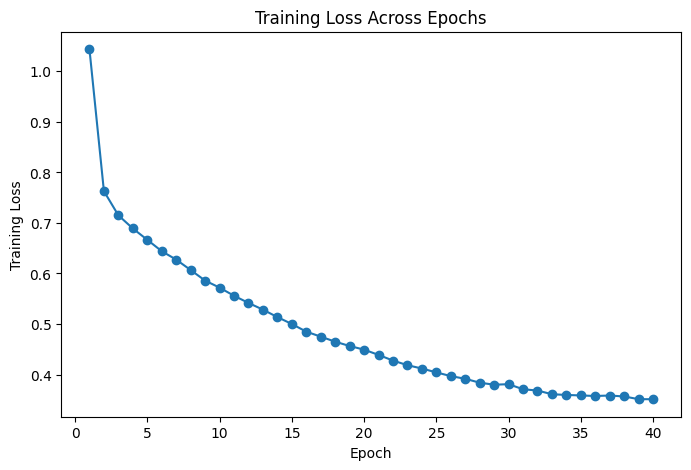

In [ ]:
# Plot training history
# your code here
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Across Epochs")
plt.show()

### Q1.9 - Perplexity for Language Models

Implement a function `calculate_perplexity` for your trained character-level language model.

It should:
1. run the model over the full dataset
2. accumulate the summed negative log-likelihood
3. divide by the total number of target characters
4. exponentiate the average loss to obtain perplexity

Because we only have one small corpus here, compute perplexity on the training data.

**Note:** For language models, perplexity is just exp(average cross-entropy loss). Lower perplexity indicates that the model assigns higher probability to the observed next characters.

In [ ]:
def calculate_perplexity(model, data_loader):
    device = next(model.parameters()).device
    model.eval()

    total_nll = 0.0
    total_targets = 0

    criterion = nn.CrossEntropyLoss(reduction="sum")

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_nll += loss.item()
            total_targets += yb.size(0)

    avg_nll = total_nll / total_targets
    perplexity = math.exp(avg_nll)
    return perplexity

perplexity = calculate_perplexity(lm_model, char_loader)

In [ ]:
print(f"Train Perplexity: {perplexity:.2f}")

Train Perplexity: 1.32


### Q1.10 - Model Assessment

Write a seed string of length `SEQ_LEN` and use it to generate at least 400 additional characters at three different temperatures.

Then discuss:
- the architecture and hyperparameter choices you settled on
- what seemed to help or hurt according to loss, perplexity, and generated text quality
- how well the model captures the whimsical Edward Lear style


In [ ]:
seed_text = text[500:600]

In [ ]:
# your code here
def generate_from_seed(model, seed, char2idx, idx2char, gen_len=400,
                       temperatures=[0.2, 0.5, 1.0], device=None):
    if device is None:
        device = next(model.parameters()).device

    assert len(seed) == SEQ_LEN, f"Seed length must be {SEQ_LEN}"

    model.eval()

    for temperature in temperatures:
        current_seed = seed
        generated = ""

        print(f"\n{'='*80}")
        print(f"Temperature: {temperature}")
        print("Seed:")
        print(seed)
        print("\nGenerated text:")

        for _ in range(gen_len):
            x = np.array([[char2idx[ch] for ch in current_seed]], dtype=np.int64)
            x_tensor = torch.tensor(x, dtype=torch.long, device=device)

            with torch.no_grad():
                logits = model(x_tensor)
                probs = F.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()

            next_idx = sample(probs, temperature=temperature)
            next_char = idx2char[next_idx]

            generated += next_char
            current_seed = current_seed[1:] + next_char

        print(generated)

In [ ]:
generate_from_seed(
    lm_model,
    seed_text,
    char2idx,
    idx2char,
    gen_len=400,
    temperatures=[0.2, 0.5, 1.0],
    device=device
)


Temperature: 0.2
Seed:
author, edward lear. london, 1862. * * * * * [illustration] there was an old man with a nose, who sa

Generated text:
te in a dish of comfortabing; when they said, "it's enough!" they only said, "a songhy-bonghy-bò! i would sit on the folking flea." and the old fish for the yonghy-bonghy-bò. "i am tired of living comment, you can! the town! g [illustration] g was happy and street you what litwory; and, on the whole into a tremble-bemble: so one of them drowned in the shade,-- having placed the room, and pictures.

Temperature: 0.5
Seed:
author, edward lear. london, 1862. * * * * * [illustration] there was an old man with a nose, who sa

Generated text:
te in a bottle; when she said, "it's enough!" they said, "if you came this wall, my own darling crowl, and all about, my look away in a sieve, to the dreadful manner she memaint on the chankly bore. and we presently to fores about brigg. [illustration] there was an old person of bantry, who flew large bird and gra

I ultimately used a character-level GRU language model with embedding dimension 128, hidden size 256, and two recurrent layers. Compared with earlier one-layer and smaller models, this architecture produced a much lower training perplexity of 1.32 and noticeably better generated text. The larger hidden representation and deeper recurrent structure improved the model's ability to capture local phrase patterns, punctuation structure, and whimsical nonsense-like wording from the Edward Lear corpus.

Across temperatures, 0.2 produced the most coherent and stylistically recognizable text, though it still showed some repetition. Temperature 0.5 gave the best balance between coherence and diversity, and often produced text that felt playful and Lear-like without collapsing too quickly into repetition. Temperature 1.0 was the most creative but also the least stable, with more distorted words and reduced grammatical consistency. Overall, the final model captured many of the surface features of Lear's whimsical style, including repetitive rhythmic phrasing, dialogue-like structure, and invented word forms, although long-range coherence remained imperfect.

<a id="part2"></a>

## Part II: Named Entity Recognition

Named entity recognition (NER) seeks to locate and classify named entities present in unstructured text into categories such as organizations, locations, times, persons, and so on.

In this part, you will preprocess a tagged sequence dataset, convert it to padded integer representations, train a bidirectional recurrent model in PyTorch, inspect its learned latent representations, and analyze performance using class-wise F1 scores.


In [ ]:

# Load the NER data
file_path = "https://storage.googleapis.com/cs109b/nlp/ner_dataset.csv"
data = pd.read_csv(file_path, encoding="latin1")
data = data.fillna(method="ffill")
print("Shape:", data.shape)
data.head(15)


Shape: (1048575, 4)


,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O
5,Sentence: 1,through,IN,O
6,Sentence: 1,London,NNP,B-geo
7,Sentence: 1,to,TO,O
8,Sentence: 1,protest,VB,O
9,Sentence: 1,the,DT,O


### Q2.1.1 - Creating the Vocabulary

Create a sorted list `words` of unique tokens found in the `'Word'` column. Store the length of this list as `n_words`, and print `n_words`.

**Note:** Do not modify capitalization and do not remove numerical or special characters.


In [ ]:
# your code here
words = sorted(data["Word"].unique())
n_words = len(words)

In [ ]:

print("n_words:", n_words)


n_words: 35177


### Q2.1.2 - Unique Tags

Create a sorted list `tags` of the unique values in the `'Tag'` column. Store the length of this list as `n_tags`, and print it.


In [ ]:
# your code here
tags = sorted(data["Tag"].unique())
n_tags = len(tags)

In [ ]:
print("n_tags:", n_tags)

n_tags: 17


### Q2.1.3 - Sentences of Input-Target Pairs

Process the dataframe into a list called `sentences`, where each element is itself a list of `(word, tag)` tuples for a single sentence.

**Note:** The raw dataframe is at the token level, not the sentence level. Before building a sequence model, you need to regroup the rows so that each sentence becomes a list of (word, tag) pairs in the original order.

In [ ]:
# your code here
sentences = data.groupby("Sentence #").apply(
    lambda s: list(zip(s["Word"], s["Tag"]))
).tolist()

In [ ]:
sentences[0]

[('Thousands', 'O'),
 ('of', 'O'),
 ('demonstrators', 'O'),
 ('have', 'O'),
 ('marched', 'O'),
 ('through', 'O'),
 ('London', 'B-geo'),
 ('to', 'O'),
 ('protest', 'O'),
 ('the', 'O'),
 ('war', 'O'),
 ('in', 'O'),
 ('Iraq', 'B-geo'),
 ('and', 'O'),
 ('demand', 'O'),
 ('the', 'O'),
 ('withdrawal', 'O'),
 ('of', 'O'),
 ('British', 'B-gpe'),
 ('troops', 'O'),
 ('from', 'O'),
 ('that', 'O'),
 ('country', 'O'),
 ('.', 'O')]

### Q2.1.4 - Maximum Sentence Length

Find the number of words in the longest sentence and store it as `max_len`. Print the result.


In [ ]:
# your code here
max_len = max(len(s) for s in sentences)

In [ ]:

print("max_len:", max_len)

max_len: 104


### Q2.1.5 - Word Encoding

Create:
- `word2idx`, a dictionary mapping each distinct word to an integer
- `idx2word`, the inverse mapping

**Important:** start indices at `1` and reserve `0` for padding.


In [ ]:
# your code here
word2idx = {w: i + 1 for i, w in enumerate(words)}
idx2word = {i: w for w, i in word2idx.items()}

### Q2.1.6 - Prepare X

Construct `X` as a list of lists, where each inner list is a sentence encoded as word indices using `word2idx`.


In [ ]:
# your code here
X = [[word2idx[word] for word, tag in sentence] for sentence in sentences]

### Q2.1.7 - Pad X

Pad all encoded input sentences to length `max_len` using left-padding with `0`, and convert the result to a numpy array called `X`.

**Note:** Because this is a sequence labeling task, you must pad both the input word sequences and the target tag sequences to the same length. If a real word is at position j in X, its corresponding real tag should also be at position j in y. Reserve 0 for padding in both cases so that the padded positions can later be ignored in the loss and metrics.


In [ ]:
# your code here
X = np.array([
    [0] * (max_len - len(sentence)) + sentence
    for sentence in X
])

In [ ]:

print("Sentence 1:", X[0])
print("X shape:", X.shape)


Sentence 1: [    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0 15077 27700 20969 24218
 26434 33389  9685 33464 29396 33246 34660 24853  8205 17364 20924 33246
 34973 27700  4011 33786 23512 33242 20368    25]
X shape: (47959, 104)


### Q2.1.8 - Tag Encoding

Create:
- `tag2idx`, a dictionary mapping each named-entity tag to an integer
- `idx2tag`, the inverse mapping

**Important:** start indices at `1` and reserve `0` for padding.


In [ ]:

# your code here
tag2idx = {tag: i + 1 for i, tag in enumerate(tags)}
idx2tag = {i: tag for tag, i in tag2idx.items()}

### Q2.1.9 - Prepare Y

Construct `y` as a list of lists, where each inner list is a sentence's tag sequence encoded with `tag2idx`.


In [ ]:
# your code here
y = [[tag2idx[tag] for word, tag in sentence] for sentence in sentences]

### Q2.1.10 - Pad Y

Pad all encoded target sequences to length `max_len` using left-padding with `0`, and convert the result to a numpy array called `y`.


In [ ]:
# your code here
y = np.array([
    [0] * (max_len - len(sentence)) + sentence
    for sentence in y
])

In [ ]:

print("y shape:", y.shape)
print("Example target row:", y[0])


y shape: (47959, 104)
Example target row: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 17 17 17 17 17 17  3 17 17 17 17 17  3 17 17 17
 17 17  4 17 17 17 17 17]


### Q2.1.11 - Train / Validation / Test Split

Construct train, validation, and test splits by:
1. splitting off 10% for test
2. then splitting 10% of the remainder for validation

Use `random_state = 109` for both calls to `train_test_split`.

Then create three PyTorch `DataLoader`s called:
- `ner_train_loader`
- `ner_val_loader`
- `ner_test_loader`


In [ ]:
X_temp, X_te, y_temp, y_te = train_test_split(
    X, y, test_size=0.10, random_state=109
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.10, random_state=109
)

X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_te_t = torch.tensor(X_te, dtype=torch.long)
y_te_t = torch.tensor(y_te, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_te_t, y_te_t)

batch_size = 32

ner_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
ner_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
ner_test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:

print("train size:", len(X_train))
print("val size:", len(X_val))
print("test size:", len(X_te))


train size: 38846
val size: 4317
test size: 4796


### Q2.2.1 - Build and Fit the NER Model

Build a recurrent NER model in PyTorch with the following components:

- an embedding layer with output dimension `50`
- a dropout layer
- a bidirectional GRU with hidden size `100` in each direction
- a final linear layer producing logits over all possible tags

Because this is a sequence tagging problem, the model should return logits for every timestep.

Define:
- `ner_model`
- `ner_criterion`
- `ner_optimizer`

Then train the model, save the best checkpoint, and plot the training history.

**Note:** Unlike the section sentiment models, this is a many-to-many problem. The model should return logits for every timestep, so its output should have shape (batch_size, seq_len, n_tags_plus_padding), not just one prediction per sentence. Since 0 is reserved for padding in the tag sequences, use a loss that ignores padded positions, such as `CrossEntropyLoss(ignore_index=0)`.

In [ ]:
# your code here
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

class NERTagger(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )
        self.dropout = nn.Dropout(dropout)
        self.bigru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, num_tags)

    def forward(self, x, return_hidden=False):
        x = self.embedding(x)
        x = self.dropout(x)
        hidden_states, _ = self.bigru(x)
        hidden_states = self.dropout(hidden_states)
        logits = self.fc(hidden_states)

        if return_hidden:
            return logits, hidden_states
        return logits

vocab_size = n_words + 1
num_tags = n_tags + 1

ner_model = NERTagger(
    vocab_size=vocab_size,
    embedding_dim=50,
    hidden_dim=100,
    num_tags=num_tags,
    dropout=0.3
).to(DEVICE)

ner_criterion = nn.CrossEntropyLoss(ignore_index=0)
ner_optimizer = torch.optim.Adam(ner_model.parameters(), lr=0.001)

cuda


In [ ]:

print(ner_model)
with torch.no_grad():
    sample_logits = ner_model(next(iter(ner_train_loader))[0][:4].to(DEVICE))
print("sample logits shape:", tuple(sample_logits.shape))


NERTagger(
  (embedding): Embedding(35178, 50, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (bigru): GRU(50, 100, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=200, out_features=18, bias=True)
)
sample logits shape: (4, 104, 18)


In [ ]:

# Train model
# your code here
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    total_tokens = 0
    total_correct = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        logits = model(xb)
        B, L, C = logits.shape

        loss = criterion(
            logits.reshape(B * L, C),
            yb.reshape(B * L)
        )

        if optimizer is not None:
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            mask = (yb != 0)
            preds = torch.argmax(logits, dim=-1)
            total_correct += ((preds == yb) & mask).sum().item()
            total_tokens += mask.sum().item()
            total_loss += loss.item() * mask.sum().item()

    avg_loss = total_loss / total_tokens
    avg_acc = total_correct / total_tokens
    return avg_loss, avg_acc


In [ ]:
checkpoint_path = "best_ner_checkpoint.pt"
num_epochs = 10

if os.path.exists(checkpoint_path):
    print("Loading saved checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    ner_model.load_state_dict(checkpoint["model_state_dict"])
    ner_optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    train_accs = checkpoint["train_accs"]
    val_accs = checkpoint["val_accs"]
    best_val_loss = checkpoint["best_val_loss"]
else:
    print("No checkpoint found. Training model...")

    best_val_loss = float("inf")
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        train_loss, train_acc = run_epoch(
            ner_model, ner_train_loader, ner_criterion, ner_optimizer, DEVICE
        )
        val_loss, val_acc = run_epoch(
            ner_model, ner_val_loader, ner_criterion, optimizer=None, device=DEVICE
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "model_state_dict": ner_model.state_dict(),
                "optimizer_state_dict": ner_optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_accs": train_accs,
                "val_accs": val_accs,
            }, checkpoint_path)
            print(f"Saved best checkpoint at epoch {epoch+1}, val_loss={val_loss:.4f}")

No checkpoint found. Training model...
Saved best checkpoint at epoch 1, val_loss=0.2593
Saved best checkpoint at epoch 2, val_loss=0.1922
Saved best checkpoint at epoch 3, val_loss=0.1640
Saved best checkpoint at epoch 4, val_loss=0.1505
Saved best checkpoint at epoch 5, val_loss=0.1371
Saved best checkpoint at epoch 6, val_loss=0.1320
Saved best checkpoint at epoch 7, val_loss=0.1250
Saved best checkpoint at epoch 8, val_loss=0.1240
Saved best checkpoint at epoch 9, val_loss=0.1198
Saved best checkpoint at epoch 10, val_loss=0.1179


In [ ]:
print(f"Best checkpoint saved to {checkpoint_path} with val_loss={best_val_loss:.4f}")

Best checkpoint saved to best_ner_checkpoint.pt with val_loss=0.1179


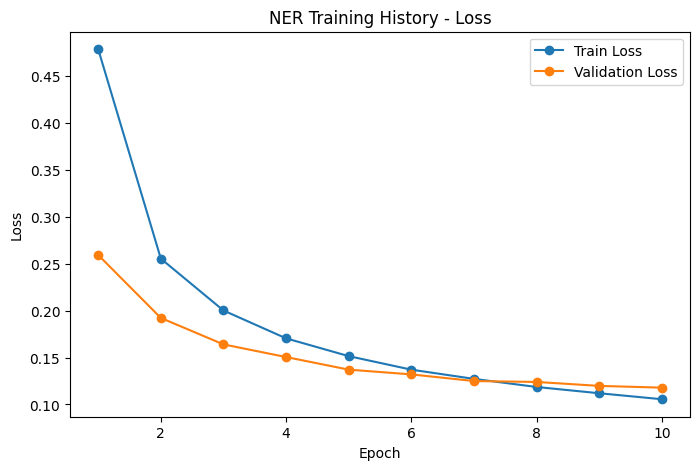

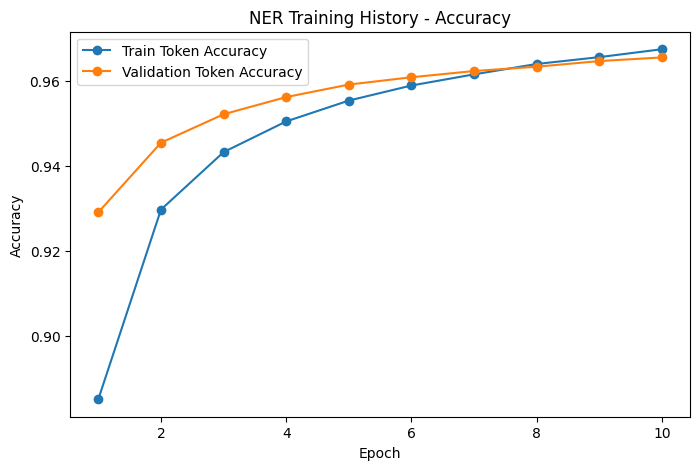

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NER Training History - Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accs, marker="o", label="Train Token Accuracy")
plt.plot(epochs, val_accs, marker="o", label="Validation Token Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("NER Training History - Accuracy")
plt.legend()
plt.show()

### Q2.2.2 - Visualizing the Latent Space

Visualize the hidden representations learned by your bidirectional GRU.

Create a 2D PCA projection of the hidden states from the recurrent layer, and make two subplots:
- one for `B-` tags
- one for `I-` tags

Then comment on any visible structure or overlap.

**Note:** When analyzing hidden states, exclude padded positions. The PCA should reflect the model’s representations of real tokens, not artificial padding tokens.


In [ ]:

# Helper functions
def visualize_B_I(pca_result, y_flat):
    tag_names = np.array([idx2tag[int(idx)] for idx in y_flat])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, prefix in zip(axes, ["B-", "I-"]):
        tags_this_panel = sorted({t for t in tag_names if t.startswith(prefix)})
        for tag in tags_this_panel:
            idx = np.where(tag_names == tag)[0]
            ax.scatter(
                pca_result[idx, 0],
                pca_result[idx, 1],
                s=4,
                alpha=0.5,
                label=tag,
            )
        ax.set_title(f"{prefix} tags")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(markerscale=3, fontsize=8)

    plt.suptitle("PCA of BiGRU Hidden States")
    plt.tight_layout()
    plt.show()

def get_hidden_output_pca(model, X_test, y_test, max_points=20000):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.long, device=DEVICE)
        _, hidden = model(X_tensor, return_hidden=True)

    hidden = hidden.cpu().numpy().reshape(-1, hidden.shape[-1])
    y_flat = y_test.reshape(-1)

    mask = y_flat != 0
    hidden = hidden[mask]
    y_flat = y_flat[mask]

    if len(y_flat) > max_points:
        idx = np.random.choice(len(y_flat), size=max_points, replace=False)
        hidden = hidden[idx]
        y_flat = y_flat[idx]

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(hidden)
    print(f"Variance explained by first 2 PCs: {pca.explained_variance_ratio_.sum():.4f}")
    return pca_result, y_flat


Variance explained by first 2 PCs: 0.2507


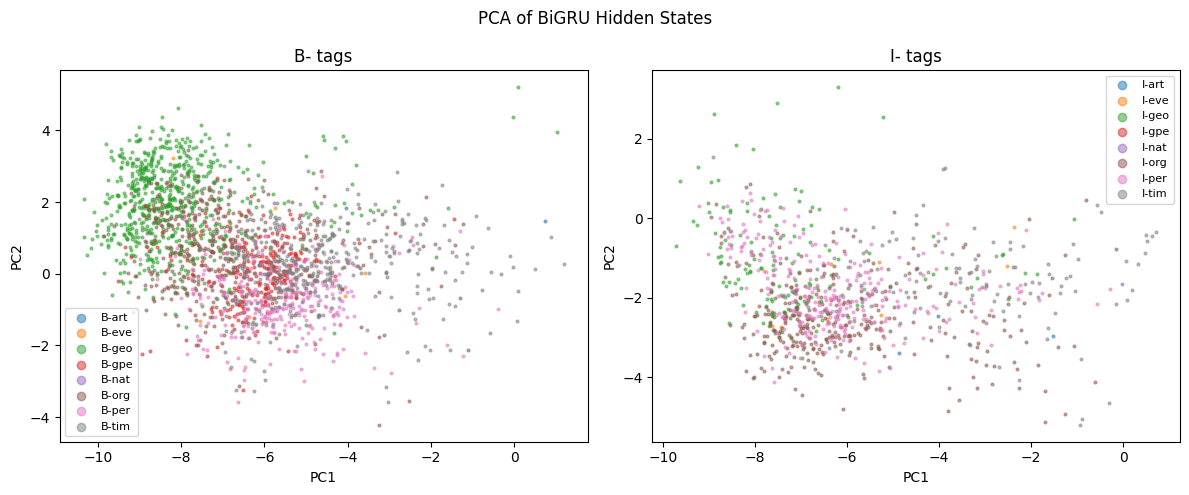

In [ ]:
pca_result, y_flat = get_hidden_output_pca(ner_model, X_te, y_te)
visualize_B_I(pca_result, y_flat)

<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


The PCA plots show that the BiGRU hidden states contain some tag-related structure, but the separation is only partial. In the B-tag panel, a few categories form loose local groupings, especially B-geo, which appears more concentrated toward the left side of the projection. However, there is still substantial overlap among most B-tags in the central region. In the I-tag panel, the overlap is even stronger, with most categories mixed together and only weak clustering visible for a few tags. Overall, this suggests that the recurrent model has learned representations that capture some entity-boundary and entity-type information, but the classes are not cleanly separable in two PCA dimensions.

<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


### Q2.3.1 - Computing & Plotting F1 Scores

Use your trained NER model to predict on the test set. Compute an F1 score for each tag category (excluding padding) and store the result in `f1_scores`.

Then create a well-labeled bar plot showing the per-tag F1 scores.

**Note:** Compute F1 scores at the token level after masking out padding, not at the sentence level. Padding should not be treated as a class, and it should not contribute to the metric.

In [ ]:

# Calculate F1 scores
# your code here
ner_model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in ner_test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = ner_model(xb)                      # (B, L, C)
        preds = torch.argmax(logits, dim=-1)       # (B, L)

        all_preds.append(preds.cpu().numpy())
        all_true.append(yb.cpu().numpy())

# stack and flatten
y_pred = np.concatenate(all_preds, axis=0).reshape(-1)
y_true = np.concatenate(all_true, axis=0).reshape(-1)

# remove padding positions
mask = y_true != 0
y_pred = y_pred[mask]
y_true = y_true[mask]

# compute per-tag F1 scores, excluding padding
f1_scores = {}
for tag_idx in range(1, n_tags + 1):
    tag_name = idx2tag[tag_idx]
    f1 = f1_score(y_true == tag_idx, y_pred == tag_idx)
    f1_scores[tag_name] = f1

print(f1_scores)

{'B-art': 0.0, 'B-eve': 0.4, 'B-geo': 0.86337513061651, 'B-gpe': 0.9448564979039019, 'B-nat': 0.4827586206896552, 'B-org': 0.7254540668596999, 'B-per': 0.7936507936507936, 'B-tim': 0.8922841864018335, 'I-art': 0.0, 'I-eve': 0.35555555555555557, 'I-geo': 0.7880055788005579, 'I-gpe': 0.75, 'I-nat': 0.0, 'I-org': 0.7881535207011182, 'I-per': 0.8423488573908012, 'I-tim': 0.7653936087295401, 'O': 0.9893051437701478}


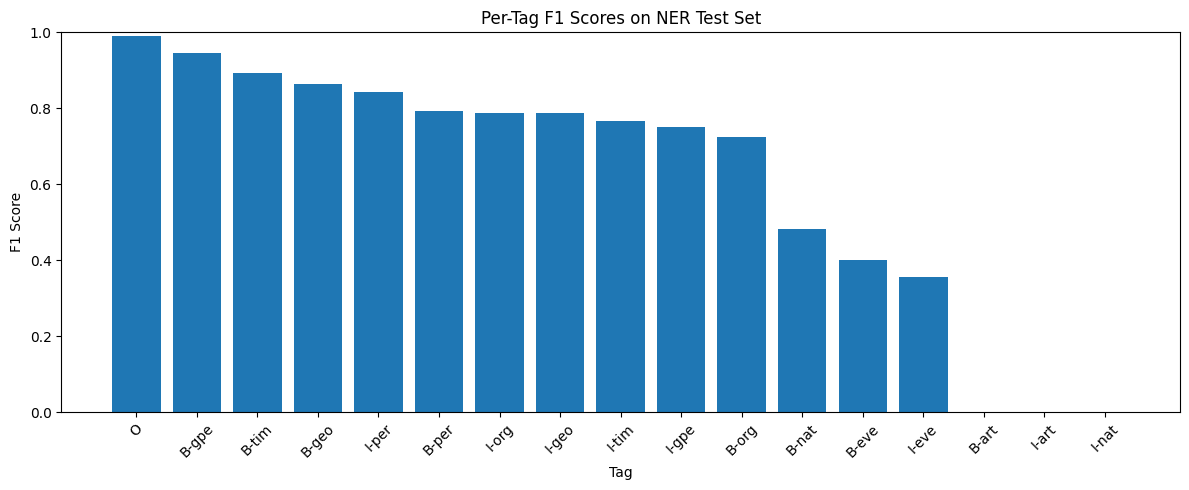

In [ ]:

# Plot F1 scores
# your code here
f1_scores = dict(sorted(f1_scores.items(), key=lambda x: x[1], reverse=True))

tags_plot = list(f1_scores.keys())
scores_plot = list(f1_scores.values())

plt.figure(figsize=(12, 5))
plt.bar(tags_plot, scores_plot)
plt.xlabel("Tag")
plt.ylabel("F1 Score")
plt.title("Per-Tag F1 Scores on NER Test Set")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Q2.3.2 - Discussion

Briefly discuss the model's performance across tag categories. Does anything stand out in the class-wise F1 scores or the latent-space visualization? If so, what could be done in future iterations to address it?


<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


The model performs well on common tags such as `O`, `B-gpe`, `B-tim`, and `B-geo`, but much worse on rare tags such as `art`, `eve`, and `nat`, with some F1 scores equal to 0. This likely reflects class imbalance, since rare tags provide much less training signal.

The latent-space plots show some local clustering, especially for a few `B-` tags, but there is still substantial overlap across categories, and the overlap is even stronger for `I-` tags. This suggests that the model has learned some tag-related structure, but the hidden representations are not cleanly separated. In future iterations, performance could be improved by handling class imbalance more directly, such as with class-weighted loss or oversampling, and by using a stronger sequence-labeling model such as BiGRU + CRF.


<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


<a id="part3"></a>

## Part III: Transformer-Based Text Classification

In this part, you will fine-tune a pretrained transformer for abstract classification. You will first work with BERT and then, for the graduate extension, optionally compare it to DeBERTa.

The goal is to classify whether an abstract is irrelevant (`0`) or not irrelevant (`1`).


### Q3.1 - Loading the Abstract Data

Load the CSV files:
- `review_78678_irrelevant.csv`
- `review_78678_not_irrelevant_included.csv`
- `review_78678_not_irrelevant_excluded.csv`

into three pandas DataFrames from the local `data/` directory.

Add a new column called `target` with:
- `0` for the irrelevant dataframe
- `1` for the two not-irrelevant dataframes


In [ ]:

# your code here


irrelevant_df = pd.read_csv(DATA_ROOT / "review_78678_irrelevant.csv")
not_irrelevant_included_df = pd.read_csv(DATA_ROOT / "review_78678_not_irrelevant_included.csv")
not_irrelevant_excluded_df = pd.read_csv(DATA_ROOT / "review_78678_not_irrelevant_excluded.csv")

# add target column
irrelevant_df["target"] = 0
not_irrelevant_included_df["target"] = 1
not_irrelevant_excluded_df["target"] = 1

# quick check
print("irrelevant_df shape:", irrelevant_df.shape)
print("not_irrelevant_included_df shape:", not_irrelevant_included_df.shape)
print("not_irrelevant_excluded_df shape:", not_irrelevant_excluded_df.shape)

print("\nirrelevant target counts:")
print(irrelevant_df["target"].value_counts())

print("\nnot_irrelevant_included target counts:")
print(not_irrelevant_included_df["target"].value_counts())

print("\nnot_irrelevant_excluded target counts:")
print(not_irrelevant_excluded_df["target"].value_counts())


irrelevant_df shape: (3912, 17)
not_irrelevant_included_df shape: (67, 17)
not_irrelevant_excluded_df shape: (480, 17)

irrelevant target counts:
target
0    3912
Name: count, dtype: int64

not_irrelevant_included target counts:
target
1    67
Name: count, dtype: int64

not_irrelevant_excluded target counts:
target
1    480
Name: count, dtype: int64


### Q3.2 - Combine the DataFrames

Concatenate all three dataframes into a single dataframe called `all_data_df`.

Keep only the columns `Abstract` and `target`, then apply `dropna()`.


In [ ]:

# your code here
all_data_df = pd.concat(
    [irrelevant_df, not_irrelevant_included_df, not_irrelevant_excluded_df],
    ignore_index=True
)

all_data_df = all_data_df[["Abstract", "target"]].dropna()

In [ ]:

print("Shape:", all_data_df.shape)
print(all_data_df["target"].value_counts(normalize=True))
all_data_df.head()


Shape: (4318, 2)
target
0    0.874016
1    0.125984
Name: proportion, dtype: float64


,Abstract,target
0,This study was carried out to know the prevale...,0
1,We attempted to determine the seropositivity o...,0
2,Human herpesvirus 8 (HHV-8) infection is commo...,0
3,338 women with age ranging from 15 to 69 years...,0
4,Antenatal screening and treatment for sexually...,0


### Q3.3 - Train / Validation Split

Use `train_test_split` to split the data into:
- `train_x`, `train_y`
- `validate_x`, `validate_y`

Use a 90% / 10% split, stratify on the target, and set `random_state = 109`.


In [ ]:

# your code here
train_x, validate_x, train_y, validate_y = train_test_split(
    all_data_df["Abstract"],
    all_data_df["target"],
    test_size=0.10,
    stratify=all_data_df["target"],
    random_state=109
)

In [ ]:

print("train size:", len(train_x))
print("validation size:", len(validate_x))


train size: 3886
validation size: 432


### Q3.4 - BERT Tokenization

Load the tokenizer for `'bert-base-uncased'` using `AutoTokenizer`.

Then:
- choose a reasonable `max_length` no larger than `512`
- tokenize both the training and validation abstracts
- store the tokenized outputs as `train_x_processed` and `validate_x_processed`

Be sure the resulting tokenized objects contain at least:
- `input_ids`
- `attention_mask`

**Note:** Unlike the earlier sequence models, these transformers require a specific tokenizer to be used. The tokenizer converts each abstract into integer token IDs and also creates an `attention_mask`, which tells the model which positions are real tokens and which are just padding. Truncation and padding are both necessary here so that examples in the same batch all have the same length.

In [ ]:

# your code here
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

MAX_LENGTH = 256

train_x_processed = tokenizer(
    list(train_x),
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

validate_x_processed = tokenizer(
    list(validate_x),
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

In [ ]:

print("max_length:", max_length)
print(train_x_processed.keys())
print("train input_ids shape:", tuple(train_x_processed["input_ids"].shape))
print("validation input_ids shape:", tuple(validate_x_processed["input_ids"].shape))


max_length: 256
dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])
train input_ids shape: (3886, 256)
validation input_ids shape: (432, 256)


### Q3.5 - PyTorch Dataset / DataLoader Pipeline

Build PyTorch datasets and dataloaders for the BERT task.

Create:
- a dataset class that returns `input_ids`, `attention_mask`, and `labels`
- a training dataloader called `train_loader`
- a validation dataloader called `validation_loader`

Use batch size `16`.

**Note:** For Hugging Face classification models, each batch is usually a dictionary containing tensors such as `input_ids`, `attention_mask`, and `labels`, rather than a simple (X, y) pair like in some earlier PyTorch examples.


In [ ]:

# your code here
class BertDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx]
        }

train_dataset = BertDataset(train_x_processed, train_y)
validation_dataset = BertDataset(validate_x_processed, validate_y)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)

In [ ]:

print("train_loader batches:", len(train_loader))
print("validation_loader batches:", len(validation_loader))
batch = next(iter(train_loader))
print({k: tuple(v.shape) for k, v in batch.items()})


train_loader batches: 243
validation_loader batches: 27
{'input_ids': (16, 256), 'attention_mask': (16, 256), 'labels': (16,)}


### Q3.6 - Build Pre-Trained BERT

Load the pretrained `'bert-base-uncased'` model for sequence classification in PyTorch.

Define:
- `bert_model`
- `bert_optimizer`

Use an appropriate optimizer and learning rate for fine-tuning. Display the model and report the number of trainable parameters.

**Note:** In section, BERT was used mainly to illustrate contextual embeddings. Here, you are doing fine-tuning: starting from a pretrained model and then updating its weights on your classification task, rather than just using frozen embeddings as input to a separate model.

This is still a binary classification problem, but in this homework we use the standard Hugging Face two-logit formulation (`num_labels=2`) rather than a single-logit sigmoid formulation.


In [ ]:

# your code here
bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
bert_model.to(DEVICE)

bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5)

n_trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:

print(bert_model)
print(f"Trainable parameters: {n_trainable_params:,}")


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### Q3.7 - Fit BERT to the Classification Task

Train BERT while monitoring validation performance.

Your solution should:
- save the best checkpoint
- avoid retraining if a saved checkpoint already exists
- track at least training loss, validation loss, and validation accuracy
- plot the training history

**Note:** Fine-tuning a transformer is much more expensive than fitting the earlier RNN models, so you should save checkpoints and reload them on reruns rather than retraining every time. Also note that the Hugging Face classification model returns an object containing both loss and logits when labels are provided. You can use the built-in loss directly during training rather than defining a separate loss function yourself.

In [ ]:

# Train BERT
# your code here
# Train BERT

checkpoint_dir = Path(CHECKPOINT_DIR) / "artifacts" if "CHECKPOINT_DIR" in globals() else ARTIFACTS_DIR
checkpoint_dir.mkdir(parents=True, exist_ok=True)

model_ckpt_path = checkpoint_dir / "bert_best_model.pt"
history_path = checkpoint_dir / "bert_history.pkl"

N_EPOCHS = 3
history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": []
}

if model_ckpt_path.exists() and history_path.exists():
    bert_model.load_state_dict(torch.load(model_ckpt_path, map_location=DEVICE))
    with open(history_path, "rb") as f:
        history = pickle.load(f)
    bert_model.to(DEVICE)
    print(f"Loaded saved checkpoint from {model_ckpt_path}. Skipping retraining.")

else:
    best_val_loss = float("inf")

    for epoch in range(N_EPOCHS):
        # training
        bert_model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            bert_optimizer.zero_grad()

            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            bert_optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # validation
        bert_model.eval()
        total_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in validation_loader:
                input_ids = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels = batch["labels"].to(DEVICE)

                outputs = bert_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                loss = outputs.loss
                logits = outputs.logits

                total_val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = total_val_loss / len(validation_loader)
        val_accuracy = correct / total

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1}/{N_EPOCHS} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"val_loss={avg_val_loss:.4f} | "
            f"val_acc={val_accuracy:.4f}"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(bert_model.state_dict(), model_ckpt_path)

    with open(history_path, "wb") as f:
        pickle.dump(history, f)

    bert_model.load_state_dict(torch.load(model_ckpt_path, map_location=DEVICE))
    bert_model.to(DEVICE)
    print(f"Best checkpoint saved to {model_ckpt_path}")

Epoch 1/3 | train_loss=0.3087 | val_loss=0.2467 | val_acc=0.9005
Epoch 2/3 | train_loss=0.2231 | val_loss=0.2068 | val_acc=0.9120
Epoch 3/3 | train_loss=0.1694 | val_loss=0.1601 | val_acc=0.9352
Best checkpoint saved to /content/drive/MyDrive/CS1090B/hw4/artifacts/bert_best_model.pt


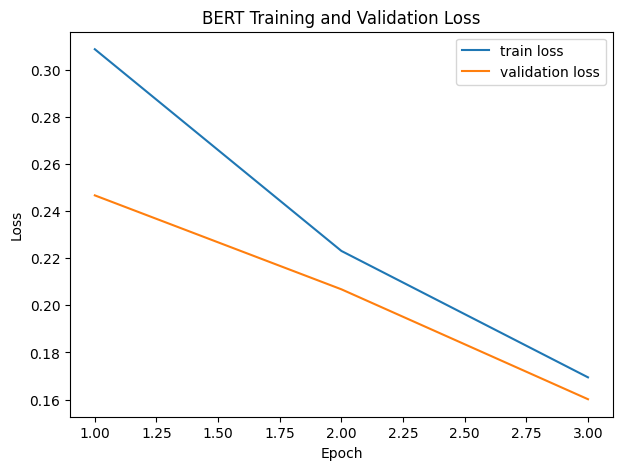

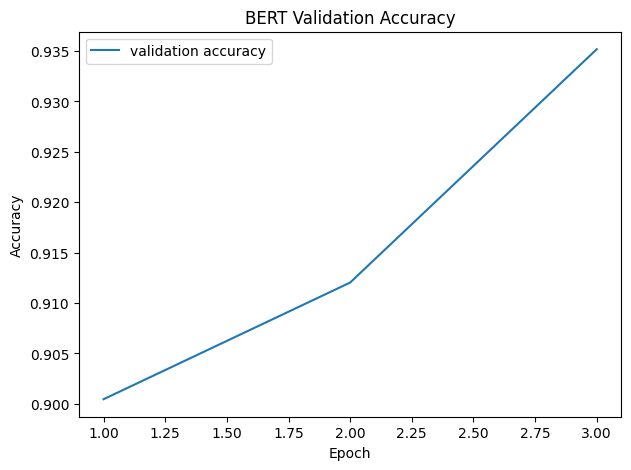

In [ ]:

# Plot Training History
# your code here


epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BERT Validation Accuracy")
plt.legend()
plt.show()

### Q3.8 - BERT Model Results

Use the validation set to:
- display a confusion matrix
- decode and display 2 abstracts the model considered highly *irrelevant*
- decode and display 2 abstracts the model considered highly *not irrelevant*

Then comment on the confusion matrix, the decoded examples, and the training history.


**Note:** High-confidence predictions are worth inspecting qualitatively. A model can be very confident for the wrong reason, so reading a few strongly predicted examples is a useful sanity check in addition to looking at aggregate metrics.

In [ ]:

# Predictions
# your code here
# Predictions

bert_model.eval()

all_logits = []
all_labels = []

with torch.no_grad():
    for batch in validation_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)

bert_probs = torch.softmax(all_logits, dim=1).numpy()
bert_preds = np.argmax(bert_probs, axis=1)
bert_true = all_labels.numpy()

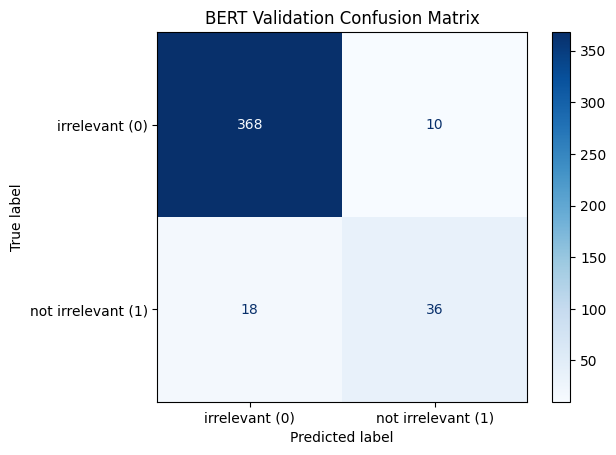

                precision    recall  f1-score   support

    irrelevant       0.95      0.97      0.96       378
not irrelevant       0.78      0.67      0.72        54

      accuracy                           0.94       432
     macro avg       0.87      0.82      0.84       432
  weighted avg       0.93      0.94      0.93       432



In [ ]:

# Confusion Matrix
# your code here
# Confusion Matrix

cm = confusion_matrix(bert_true, bert_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["irrelevant (0)", "not irrelevant (1)"]
)
disp.plot(cmap="Blues")
plt.title("BERT Validation Confusion Matrix")
plt.show()

print(classification_report(bert_true, bert_preds, target_names=["irrelevant", "not irrelevant"]))

In [ ]:

tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
n_examples = 2
irrelevant_bert = np.argsort(bert_probs[:, 1])[:n_examples]

print("Highest predicted probabilities of being irrelevant\n")
for idx in irrelevant_bert:
    abstract = tokenizer_bert.decode(
        validate_x_processed["input_ids"][idx],
        skip_special_tokens=True,
    )
    print(f"Abstract {idx}: {abstract}\n")


Highest predicted probabilities of being irrelevant

Abstract 73: to examine perceived hiv prevalence and disease burden in high - risk adults in cape town, south africa. a convenience sample of 793 male and 188 female sexually transmitted infection clinic patients completed anonymous surveys. individuals who saw themselves at greater risk for hiv / aids also perceived greater local hiv prevalence. participants presented extremely distorted views of local hiv prevalence that exceed the reality in cape town. perceiving greater local aids burden was independently associated with condom use. interventions that accurately place local aids burden in the context of places with relatively lower burden may activate protective motivations.

Abstract 315: aids - related stigma is a major contributor to the health and psychosocial well - being of children affected by aids. whilst it is often suggested that aids - affected children may be stigmatised by other children, to date no research focuses 

In [ ]:

not_irrelevant_bert = np.argsort(bert_probs[:, 1])[-n_examples:]

print("Highest predicted probabilities of being NOT irrelevant\n")
for idx in not_irrelevant_bert:
    abstract = tokenizer_bert.decode(
        validate_x_processed["input_ids"][idx],
        skip_special_tokens=True,
    )
    print(f"Abstract {idx}: {abstract}\n")


Highest predicted probabilities of being NOT irrelevant

Abstract 56: introduction bacterial vaginosis ( bv ) is a common cause of abnormal discharge in women of reproductive age. it is considered to be a major cause of significant reproductive morbidity and is increasingly associated with enhancing the transmission of hiv. it is therefore imperative to determine the occurrence of bacterial vaginosis among women of reproductive age. methods high vaginal swabs were collected from 200 consenting patients aged 18 - 45 years and tested for bacterial vaginosis. the swabs were mixed with 10 % potassium hydroxide ( koh ) on a slide. absence or presence of fishy odour was noted. a wet mount was prepared and viewed to look for clue cells and motile trichomonals and yeast. the presence of clue cells on wet microscopy, a positive amine test, abnormal vaginal discharge and ph above 4. 5 indicated bacterial vaginosis. diagnosis of trichomoniasis was based on the presence of motile trichomonas in we

<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


*Your Answer Here*

The best model was the checkpoint saved at epoch 3, which achieved a validation loss of 0.1601 and a validation accuracy of 0.9352. Its confusion matrix shows strong overall performance: 368 irrelevant abstracts were correctly classified as irrelevant, 10 irrelevant abstracts were misclassified as not irrelevant, 36 not irrelevant abstracts were correctly classified, and 18 not irrelevant abstracts were misclassified as irrelevant. This means the model performs especially well on the irrelevant class, with precision 0.95, recall 0.97, and F1-score 0.96, while performance on the not irrelevant class is weaker, with precision 0.78, recall 0.67, and F1-score 0.72. The results suggest that the model is somewhat biased toward the majority irrelevant class, which is consistent with the class imbalance in the validation set.

The decoded high-confidence examples also help explain the model’s behavior. The abstracts predicted as not irrelevant were more directly focused on clinical infection prevalence, diagnostic testing, and biomedical outcomes, while the abstracts predicted as irrelevant, although still related to HIV/AIDS, focused more on stigma, perceived burden, and social or behavioral topics. This suggests that the model learned a meaningful distinction beyond simply detecting HIV-related terms. The training history is also reassuring: both training loss and validation loss decreased steadily across all three epochs, from 0.3087 to 0.1694 for training loss and from 0.2467 to 0.1601 for validation loss, while validation accuracy improved from 0.9005 to 0.9352. Since validation loss continued to improve through epoch 3, the best checkpoint was the final epoch, and there is no clear sign of overfitting within this training window.

<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


### Q3.9 - [209] DeBERTa

**All subsequent questions are required for 209 students and optional for others.**

Repeat the tokenization, dataloader construction, model building, and training workflow from Q3.4-Q3.7, but now for the model `'microsoft/deberta-v3-base'`.

You may choose to freeze some early layers if that improves stability.

**Note:** This question follows the same overall fine-tuning pipeline as BERT, but the tokenizer and model should now come from the DeBERTa checkpoint. The main goal is to compare how a different pretrained transformer behaves when the downstream task and training procedure are otherwise similar.


In [ ]:

# Tokenization & DataLoaders
# your code here


In [ ]:

# Build DeBERTa
# your code here


In [ ]:

# Train DeBERTa
# your code here


In [ ]:

# Plot Training History
# your code here


### Q3.10 - [209] DeBERTa vs BERT Results

Display confusion matrices for both BERT and DeBERTa, and decode high-confidence examples from both models for:
- the most irrelevant predictions
- the most not-irrelevant predictions


In [ ]:

# Predictions
# your code here


In [ ]:

# Confusion Matrices
# your code here


In [ ]:

n_examples = 2
irrelevant_bert = np.argsort(bert_probs[:, 1])[:n_examples]
irrelevant_deberta = np.argsort(deberta_probs[:, 1])[:n_examples]

print("Highest predicted probabilities of being irrelevant\n")

print("BERT:")
for idx in irrelevant_bert:
    abstract = tokenizer_bert.decode(validate_x_processed["input_ids"][idx], skip_special_tokens=True)
    print(f"Abstract {idx}: {abstract}\n")

print("DeBERTa:")
for idx in irrelevant_deberta:
    abstract = tokenizer_deberta.decode(validate_x_processed_deberta["input_ids"][idx], skip_special_tokens=True)
    print(f"Abstract {idx}: {abstract}\n")


In [ ]:

not_irrelevant_bert = np.argsort(bert_probs[:, 1])[-n_examples:]
not_irrelevant_deberta = np.argsort(deberta_probs[:, 1])[-n_examples:]

print("Highest predicted probabilities of being NOT irrelevant\n")

print("BERT:")
for idx in not_irrelevant_bert:
    abstract = tokenizer_bert.decode(validate_x_processed["input_ids"][idx], skip_special_tokens=True)
    print(f"Abstract {idx}: {abstract}\n")

print("DeBERTa:")
for idx in not_irrelevant_deberta:
    abstract = tokenizer_deberta.decode(validate_x_processed_deberta["input_ids"][idx], skip_special_tokens=True)
    print(f"Abstract {idx}: {abstract}\n")


### Q3.11 - [209] DeBERTa vs BERT Model Comparison

Discuss:
- differences in the training histories
- differences in the confusion matrices and qualitative examples
- whether you used identical hyperparameters / procedures for both models
- two ways in which DeBERTa's positional treatment differs from the absolute positional encoding used in vanilla BERT


**Note:** You are not expected to derive the full transformer internals here. Focus on the big conceptual differences.

<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


*Your Answer Here*


<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


## Wrap-up

In a few sentences, describe what you found most challenging about the assignment.

Then store the amount of time you spent on the homework in `hours_spent_on_hw`.


<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


*Your Answer Here*


<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


In [ ]:

hours_spent_on_hw = ...


In [ ]:

# total notebook runtime
minutes_elapsed = (time.time() - time_start) / 60
print(f"Approximate runtime so far: {minutes_elapsed:.2f} minutes")
